In [1]:
import warnings
warnings.filterwarnings('ignore')


In [2]:
!pip install -q datasets soundfile --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 9.6 MB/s eta 0:00:00ta 0:00:01


In [3]:
import os, io, json
import numpy as np
import pandas as pd
import soundfile as sf
from datasets import load_dataset, Audio

CONFIGS = {
    "lin": "lin_asr",   # Lingala
    "sna": "sna_asr",   # Shona
    "lug": "lug_asr",   # Luganda
}

REPO = "google/WaxalNLP"
CACHE_PATH = "/kaggle/working/waxal_eda_cache.csv"
SAMPLES_PER_LANG = 400   # bounded sample -nlightweight EDA, not full pass

In [4]:
def stream_language_sample(config_key, config_name, n=SAMPLES_PER_LANG, split="train"):
    """
    Streams a config, pulls n rows, decodes only duration (fast, via soundfile.info
    on the raw bytes) + text/gender/speaker metadata. Keeps one waveform per
    language for the spectrogram plot later.
    """
    ds = load_dataset(REPO, config_name, split=split, streaming=True)
    ds = ds.cast_column("audio", Audio(decode=False))  # keep raw bytes, skip torchcodec

    rows = []
    example_waveform = None
    example_sr = None

    for i, row in enumerate(ds):
        if i >= n:
            break
        audio_bytes = row["audio"]["bytes"]
        with sf.SoundFile(io.BytesIO(audio_bytes)) as f:
            duration = len(f) / f.samplerate
            sr = f.samplerate

        rows.append({
            "lang": config_key,
            "id": row["id"],
            "speaker_id": row["speaker_id"],
            "gender": row.get("gender", ""),
            "duration_sec": duration,
            "sample_rate": sr,
            "n_words": len(row["transcription"].split()),
            "n_chars": len(row["transcription"]),
        })

        if example_waveform is None:  # grab first sample's full waveform once
            wav, sr_full = sf.read(io.BytesIO(audio_bytes))
            example_waveform, example_sr = wav, sr_full

    return pd.DataFrame(rows), example_waveform, example_sr

In [5]:
def build_or_update_cache(configs=CONFIGS):
    if os.path.exists(CACHE_PATH):
        cache_df = pd.read_csv(CACHE_PATH)
        done_langs = set(cache_df["lang"].unique())
    else:
        cache_df = pd.DataFrame()
        done_langs = set()

    waveforms = {}  

    for key, cfg in configs.items():
        if key in done_langs:
            print(f"[skip] {key} already in cache")
            continue
        print(f"[stream] {key} ({cfg}) ...")
        df, wav, sr = stream_language_sample(key, cfg)
        cache_df = pd.concat([cache_df, df], ignore_index=True)
        waveforms[key] = (wav, sr)
        cache_df.to_csv(CACHE_PATH, index=False)  # persist after each language
        print(f"[done] {key}: {len(df)} rows cached")

    return cache_df, waveforms

df, waveforms = build_or_update_cache()
df.head()

[stream] lin (lin_asr) ...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

[done] lin: 400 rows cached
[stream] sna (sna_asr) ...


...

[done] sna: 400 rows cached
[stream] lug (lug_asr) ...


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/67 [00:00<?, ?it/s]

[done] lug: 400 rows cached


,lang,id,speaker_id,gender,duration_sec,sample_rate,n_words,n_chars
0,lin,lin_24754,4rz2JZIZrUfKaxu5d9zdgrT2B1v1,Female,1.01075,48000,25,136
1,lin,lin_24796,4rz2JZIZrUfKaxu5d9zdgrT2B1v1,Female,1.01075,48000,18,100
2,lin,lin_24732,OWDZrFDhl8g2R3lZ7encCuWVrFz1,Female,16.29875,48000,37,205
3,lin,lin_24781,OWDZrFDhl8g2R3lZ7encCuWVrFz1,Female,15.38675,48000,24,148
4,lin,lin_24790,FzdvGMcP1mY2v86Jh5RDAqygN1p1,Female,16.34675,48000,21,113


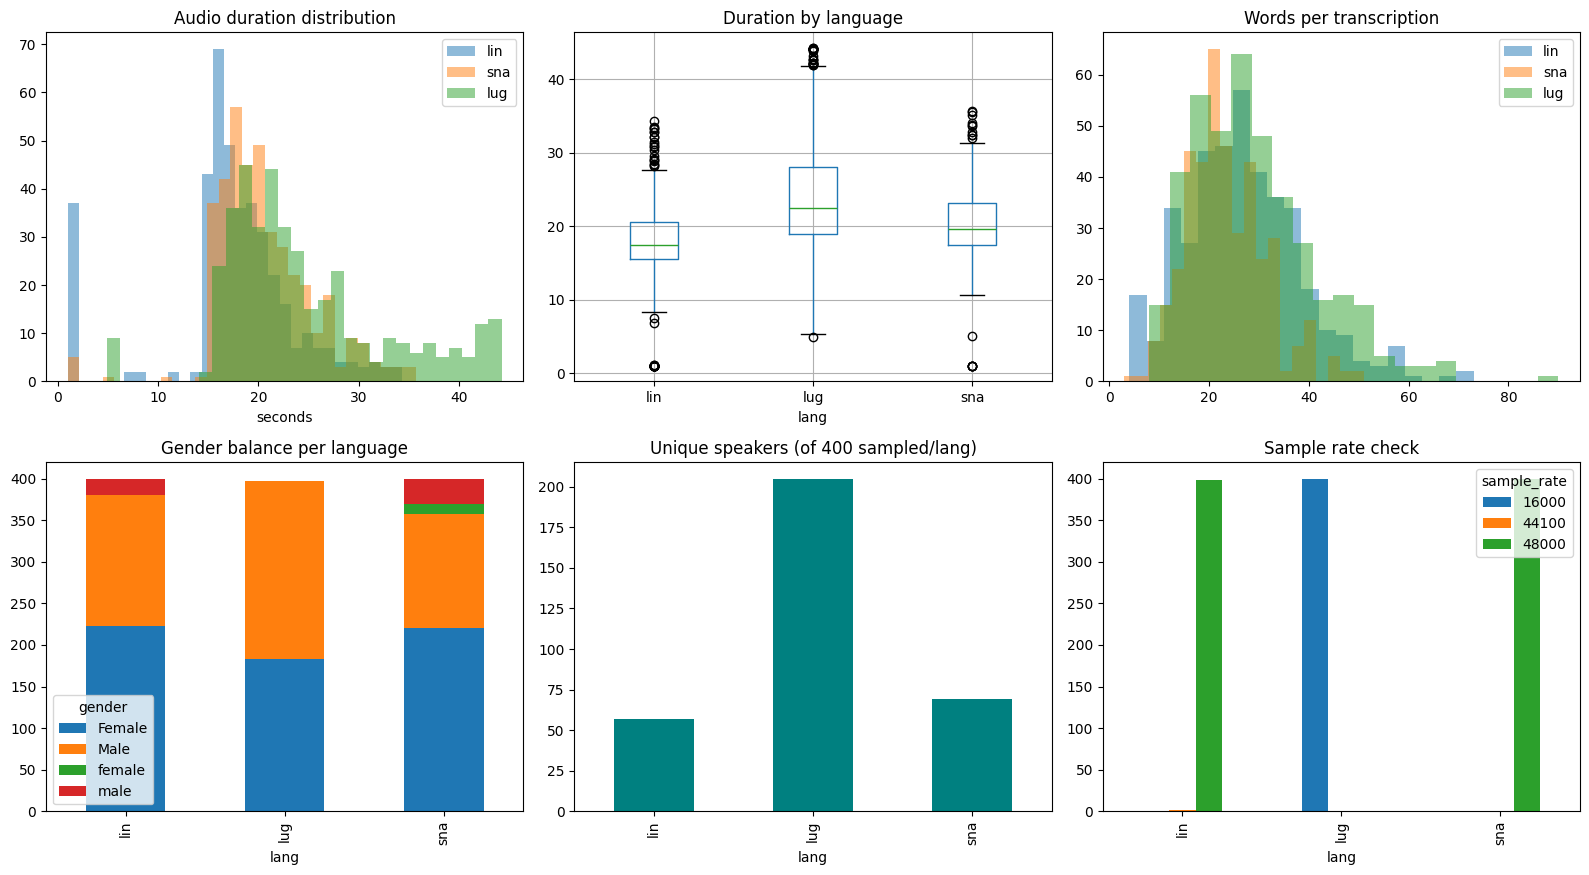

In [6]:
import matplotlib.pyplot as plt

df = pd.read_csv(CACHE_PATH)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Duration distribution per language 
for lang in df["lang"].unique():
    axes[0,0].hist(df[df.lang==lang]["duration_sec"], bins=30, alpha=0.5, label=lang)
axes[0,0].set_title("Audio duration distribution")
axes[0,0].set_xlabel("seconds"); axes[0,0].legend()

# 2. Boxplot comparison 
df.boxplot(column="duration_sec", by="lang", ax=axes[0,1])
axes[0,1].set_title("Duration by language"); plt.suptitle("")

# 3. Transcription length (words) 
for lang in df["lang"].unique():
    axes[0,2].hist(df[df.lang==lang]["n_words"], bins=20, alpha=0.5, label=lang)
axes[0,2].set_title("Words per transcription"); axes[0,2].legend()

# 4. Gender balance per language 
gender_counts = df.groupby(["lang","gender"]).size().unstack(fill_value=0)
gender_counts.plot(kind="bar", stacked=True, ax=axes[1,0])
axes[1,0].set_title("Gender balance per language")

# 5. Unique speakers sampled 
speaker_div = df.groupby("lang")["speaker_id"].nunique()
speaker_div.plot(kind="bar", ax=axes[1,1], color="teal")
axes[1,1].set_title(f"Unique speakers (of {SAMPLES_PER_LANG} sampled/lang)")

# 6. Sample rate sanity check 
sr_counts = df.groupby(["lang","sample_rate"]).size().unstack(fill_value=0)
sr_counts.plot(kind="bar", ax=axes[1,2])
axes[1,2].set_title("Sample rate check")

plt.tight_layout()
plt.savefig("/kaggle/working/waxal_eda_overview.png", dpi=120)
plt.show()

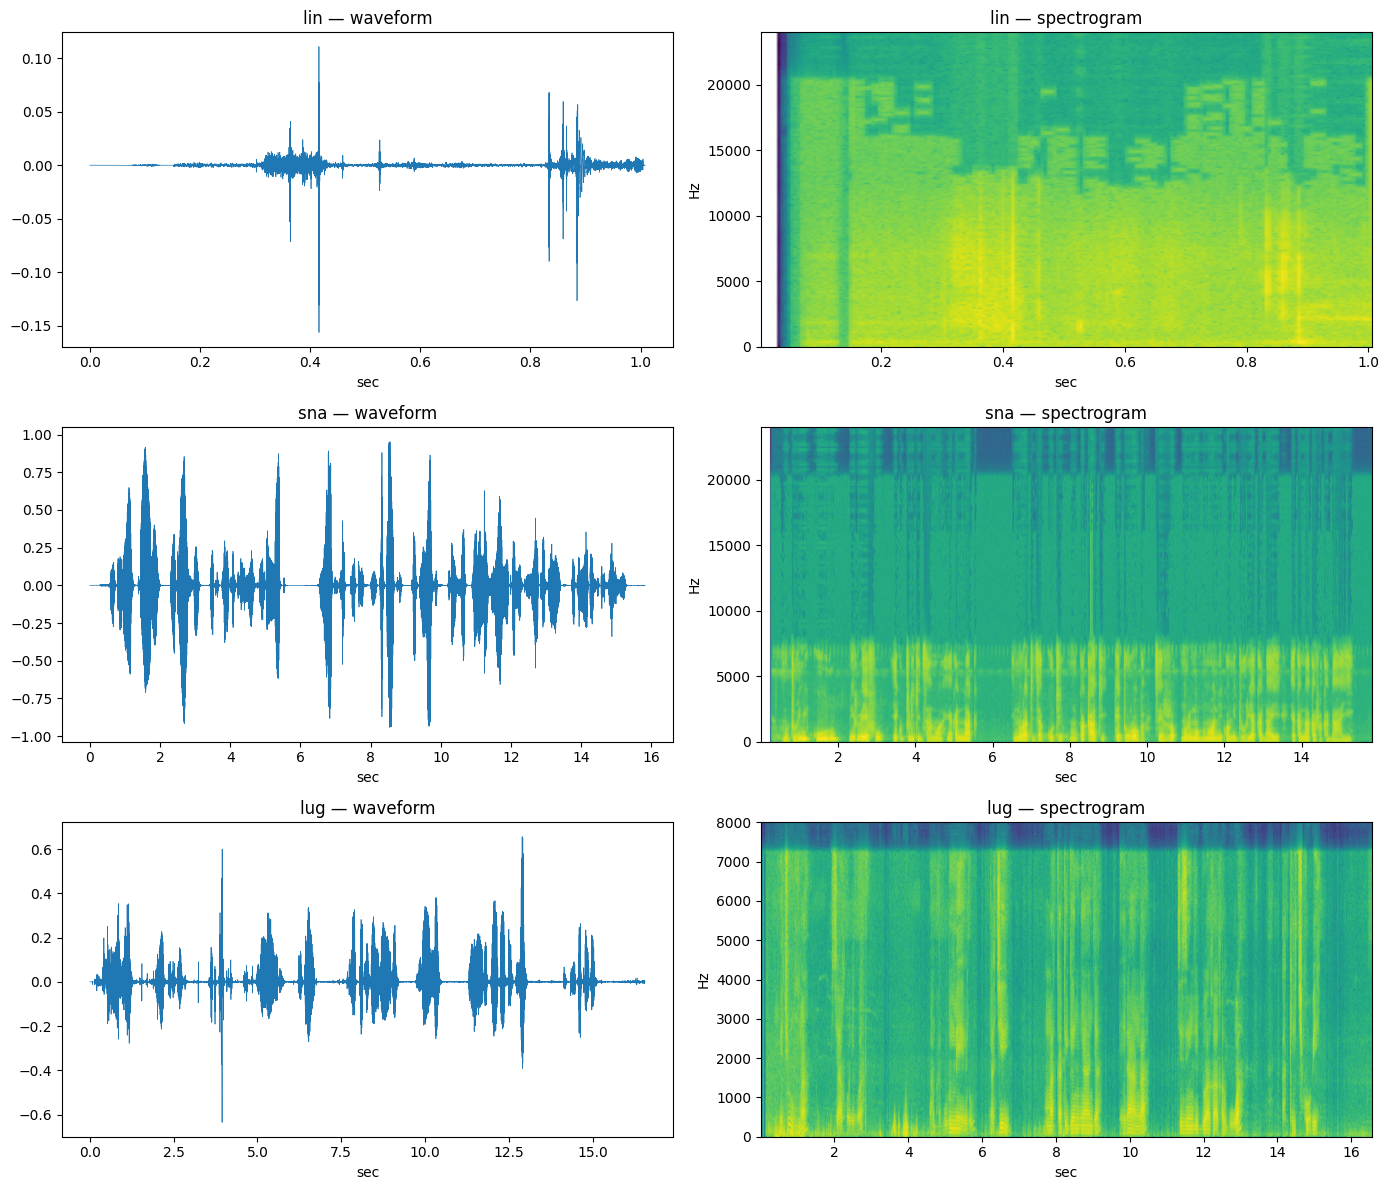

In [7]:
fig, axes = plt.subplots(len(waveforms), 2, figsize=(14, 4*len(waveforms)))
if len(waveforms) == 1:
    axes = axes.reshape(1, -1)

for i, (lang, (wav, sr)) in enumerate(waveforms.items()):
    t = np.linspace(0, len(wav)/sr, len(wav))
    axes[i,0].plot(t, wav, linewidth=0.5)
    axes[i,0].set_title(f"{lang} — waveform")
    axes[i,0].set_xlabel("sec")

    axes[i,1].specgram(wav, Fs=sr, NFFT=512, noverlap=256)
    axes[i,1].set_title(f"{lang} — spectrogram")
    axes[i,1].set_xlabel("sec"); axes[i,1].set_ylabel("Hz")

plt.tight_layout()
plt.savefig("/kaggle/working/waxal_waveforms.png", dpi=120)
plt.show()